# 분류를 위해 미세 튜닝하기 목차
* [Chapter 1 여러가지 미세 튜닝 방법](#chapter1)
* [Chapter 2 데이터셋 준비](#chapter2)
* [Chapter 3 데이터 로더 만들기](#chapter3)
* [Chapter 4 사전 훈련된 가중치로 모델 초기화하기](#chapter4)
* [Chapter 5 분류 헤드 추가하기](#chapter5)
* [Chapter 6 분류 손실과 정확도 계산하기](#chapter6)
* [Chapter 7 지도 학습 데이터로 모델 미세 튜닝하기](#chapter7)
* [Chapter 8 LLM을 스팸 분류기로 사용하기](#chapter8)

In [95]:
from importlib.metadata import version

pkgs = ["matplotlib",  # 그래프 라이브러리
        "numpy",       # 파이토치와 텐서플로의 종속성
        "tiktoken",    # 토크나이저
        "torch",       # 딥러닝 라이브러리
        "tensorflow",  # OpenAI의 사전 훈련된 가중치를 위해서
        "pandas"       # 데이터셋 로딩을 위해
       ]
for p in pkgs:
    print(f"{p} 버전: {version(p)}")

matplotlib 버전: 3.10.6
numpy 버전: 2.1.3
tiktoken 버전: 0.12.0
torch 버전: 2.8.0
tensorflow 버전: 2.19.0
pandas 버전: 2.3.3


## Chapter 1 여러가지 미세 튜닝 방법 <a class="anchor" id="chapter1"></a>
1. 언어 모델을 미세 튜닝하는 가장 일반적인 방법은 지시 미세 튜닝(instruction fine-tuning)과 분류 미세 튜닝(classification fine-tuning)입니다.
   - 지시 미세 튜닝은 구체적인 지시 데이터를 사용해 일련의 작업에서 언어 모델을 훈련한다.
      - 모델이 사용자의 구체적인 지시를 이해하고 이를 기반으로 응답을 생성하는 능력을 향상시킨다.
      - 복잡한 사용자의 지시를 기반으로 다양한 작업을 처리해야하는 모델에 잘 맞는다.
      - 다양한 작업에 능숙한 모델을 개발하려면 데이터셋과 컴퓨팅 자원이 많이 필요하다.
      - 예) 영어 문장을 독일어로 변경하라는 지시를 수행한다
   - 분류 미세 튜닝은 레이블이 있는 데이터셋을 사용해 모델이 특정 클래스에 대한 예측을 수행하도록 훈련한다.
      - 감성 분석이나 스팸 감지와같은 데이터를 사전에 정의된 클래스로 정확히 분류해야 하는 프로젝트에 적합하다
      - 데이터와 컴퓨팅 자원이 비교적 적게 필요하지만 모델이 훈련된 특정 클래스로만 사용이 제한된다.
      - 예) 모델이 텍스크가 스펨인지 아닌지 결정하는 작업을 수행한다.

      ![메세 튜닝](image/06-01-tunning2.png)

      ![메세 튜닝2](image/06-01-tunning4.png)



## Chapter 2 데이터셋 준비 <a class="anchor" id="chapter2"></a>
1. 이전에 구현하고 사전 훈련한 GPT 모델을 수정해서 분류 미세 튜닝을 수행할 수 있다.

2. 분류 미세 튜닝에 유용한 예제로 '스펨'과 '스팸 아님'으로 구성된 텍스트 메시지 데이터셋을 사용한다.
   - 텍스트 메시지는 일반적으 이메일이 아니라 핸드폰으로 전달되지만, 동일한 단계가 이메일 분류에도 적용된다.

   ![프로세스](image/06-01-process2.png)

In [132]:
import urllib.request
import zipfile
import os
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path}가 이미 있어 다운로드 및 압축 해제를 건너뜁니다.")
        return

    # 파일을 다운로드 합니다.
    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    # 파일 압축을 풉니다.
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    # .tsv 파일 확장자를 추가합니다.
    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"파일이 다운로드되어 {data_file_path}에 저장되었습니다.")

try:
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)
except (urllib.error.HTTPError, urllib.error.URLError, TimeoutError) as e:
    print(f"기본 URL 실패: {e}. 백업 URL을 시도합니다...")
    url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/sms%2Bspam%2Bcollection.zip"
    download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

sms_spam_collection/SMSSpamCollection.tsv가 이미 있어 다운로드 및 압축 해제를 건너뜁니다.


In [133]:
import pandas as pd

df = pd.read_csv(data_file_path, sep="\t", header=None, names=["Label", "Text"])
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [134]:
# 레이블 분포 조사
#   - 레이블이 'ham'인 메시지와 'spam'인 메시지의 개수를 출력
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


In [135]:
# 미세퓨닝을 빠르게 진행하기 위해 747개의 샘플만 포함되도록 데이터셋 줄이기
def create_balanced_dataset(df):

    # "스팸" 샘플 개수 세기
    num_spam = df[df["Label"] == "spam"].shape[0]

    # "스팸" 샘플 개수와 일치하도록 "햄" 샘플을 무작위로 샘플링
    ham_subset = df[df["Label"] == "ham"].sample(num_spam, random_state=123)

    # "햄"과 "스팸"을 합침
    balanced_df = pd.concat([ham_subset, df[df["Label"] == "spam"]])

    return balanced_df


balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


In [136]:
# 문자열로 된 클래스 레이블 "ham"과 "spam"을 정수로 변환
#   - 텍스트를 토큰 ID로 변환하는 것과 유사하다.
#   - 50,000개 단어 이상으로 구성된 GPT 어휘 사전을 사용하지 않고 0과 1로 레이블을 인코딩
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})
balanced_df

,Label,Text
4307,0,Awww dat is sweet! We can think of something t...
4138,0,Just got to &lt;#&gt;
4831,0,"The word ""Checkmate"" in chess comes from the P..."
4461,0,This is wishing you a great day. Moji told me ...
5440,0,Thank you. do you generally date the brothas?
...,...,...
5537,1,Want explicit SEX in 30 secs? Ring 02073162414...
5540,1,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,1,Had your contract mobile 11 Mnths? Latest Moto...
5566,1,REMINDER FROM O2: To get 2.50 pounds free call...


In [137]:
def random_split(df, train_frac, validation_frac):
    # 데이터프레임 전체 섞기
    df = df.sample(frac=1, random_state=123).reset_index(drop=True)

    # 분할 인덱스 계산
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    # 데이터프레임 분할
    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(balanced_df, 0.7, 0.1)
# 테스트 크기는 나머지에 해당하는 0.2입니다.

train_df.to_csv("train.csv", index=None)
validation_df.to_csv("validation.csv", index=None)
test_df.to_csv("test.csv", index=None)

## Chapter 3 데이터 로더 만들기 <a class="anchor" id="chapter3"></a>
1. 데이터셋 길이 정리 방법
   - 가장 짧은 길이의 메시지에 맞춰 모든 메시지를 잘라낸다.
        - 계산 비용이 저렴하지만 정보 손실이 발생할 수 있다.
   - 가장 긴 길의 메시지에 맞춰 모든 메시지에 패딩을 추가한다.
        - 정보 손실이 없지만 계산 비용이 증가한다.

2. 가장 긴 메시지의 길이로 모든 메시지를 맞추어 배치를 생성한다.
    - 짧은 길이의 메시지에 패딩 토큰을 추가한다.
    - "<|endoftext|>" 토큰에 해당하는 토큰 ID(50256)로 패딩을 수행한다.

In [138]:
# 토큰 ID 50256이 "<|endoftext|>" 토큰에 해당하는지 확인
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


3. 데이터 로더를 만들기 전에 데이터를 로드하고 처리하는 방법을 지정하기 위해 파이토치 데이터셋 클래스를 구현한다.
    - SpamDataset 클래스를 정의한다.
        - 텍스트 메시지를 토큰ID 시퀸스로 인코딩
        - 훈련 데이터셋에서 가장 긴 시퀸스를 식별
        - 모든 시퀸스에 패딩토큰을 추가하여 가장 긴 시퀸스 길이에 맞춤  

        ![패딩](image/06-01-padding2.png)

In [139]:
import torch
from torch.utils.data import Dataset


class SpamDataset(Dataset):
    def __init__(self, csv_file, tokenizer, max_length=None, pad_token_id=50256):
        self.data = pd.read_csv(csv_file)

        # 텍스트 토큰화
        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length
            # max_length보다 긴 시퀀스 자르기
            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]

        # 가장 긴 시퀀스에 맞춰 패딩하기
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length
        # 참고: 이 메서드를 구현하는 더 파이썬적인 버전은
        # 다음과 같으며, 다음 장에서도 사용됩니다.
        # return max(len(encoded_text) for encoded_text in self.encoded_texts)

In [ ]:
train_dataset = SpamDataset(
    csv_file="train.csv",
    max_length=None,
    tokenizer=tokenizer
)

print(train_dataset.max_length)

120


In [140]:
val_dataset = SpamDataset(
    csv_file="validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)
test_dataset = SpamDataset(
    csv_file="test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

4. 배치 크기 8, 배치 길이 120인 훈련 샘플과 각 샘플에 해당하는 클래스레이블로 데이터 로더 구성
    - 텍스트 메시지와 레이블을 로드하여 배치 크기 8인 훈련, 검증, 테스트 세트 데이터 로더를 만든다.

    ![데이터로더](image/06-01-batch2.png)

In [141]:
from torch.utils.data import DataLoader

num_workers = 0 # 데이터 로더에 사용할 CPU 코어 수
batch_size = 8 # 배치 크기
torch.manual_seed(123)  # 재현성을 위해 시드 설정

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

In [142]:
# 마지막 배치 텐서 차원 출력
print("훈련 세트 로더:")
for input_batch, target_batch in train_loader:
    pass

print("입력 배치 차원:", input_batch.shape)
print("레이블 배치 차원", target_batch.shape)

훈련 세트 로더:
입력 배치 차원: torch.Size([8, 120])
레이블 배치 차원 torch.Size([8])


In [143]:
print(f"{len(train_loader)}개 훈련 배치")
print(f"{len(val_loader)}개 검증 배치")
print(f"{len(test_loader)}개 테스트 배치")

130개 훈련 배치
19개 검증 배치
38개 테스트 배치


## Chapter 4 사전 훈련된 가중치로 모델 초기화하기 <a class="anchor" id="chapter4"></a>
1. 스팸 메시지를 식별하도록 분류 미세 튜닝히가 위한 모델 준비.
    - 이전에 사전 훈련한 GPT 모델을 로드한다.
    - 출력 레이어를 이진 분류를 수행하도록 수정한다.
    - 모델의 나머지 부분은 사전 훈련된 가중치로 초기화한다.

In [144]:
CHOOSE_MODEL = "gpt2-small (124M)"
INPUT_PROMPT = "Every effort moves"

BASE_CONFIG = {
    "vocab_size": 50257,     # 어휘사전 크기
    "context_length": 1024,  # 문맥 길이
    "drop_rate": 0.0,        # 드롭아웃 비율
    "qkv_bias": True         # 쿼리-키-값 편향
}

model_configs = {
    "gpt2-small (124M)": {"emb_dim": 768, "n_layers": 12, "n_heads": 12},
    "gpt2-medium (355M)": {"emb_dim": 1024, "n_layers": 24, "n_heads": 16},
    "gpt2-large (774M)": {"emb_dim": 1280, "n_layers": 36, "n_heads": 20},
    "gpt2-xl (1558M)": {"emb_dim": 1600, "n_layers": 48, "n_heads": 25},
}

BASE_CONFIG.update(model_configs[CHOOSE_MODEL])

assert train_dataset.max_length <= BASE_CONFIG["context_length"], (
    f"데이터셋 길이 {train_dataset.max_length}가 모델의 문맥 "
    f"길이 {BASE_CONFIG['context_length']}를 초과합니다. `max_length={BASE_CONFIG['context_length']}`로 "
    f"데이터 셋을 다시 초기화하십시오."
)
 

In [18]:
!wget https://bit.ly/4jZL2Gr -O gpt_download.py
!wget https://bit.ly/4esl8dj -O previous_chapters.py

--2025-10-23 08:44:37--  https://bit.ly/4jZL2Gr
Resolving bit.ly (bit.ly)... 67.199.248.10, 67.199.248.11
Connecting to bit.ly (bit.ly)|67.199.248.10|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://raw.githubusercontent.com/rickiepark/llm-from-scratch/refs/heads/main/ch06/01_main-chapter-code/gpt_download.py [following]
--2025-10-23 08:44:37--  https://raw.githubusercontent.com/rickiepark/llm-from-scratch/refs/heads/main/ch06/01_main-chapter-code/gpt_download.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6333 (6.2K) [text/plain]
Saving to: ‘gpt_download.py’

gpt_download.py     100%[===================>]   6.18K  --.-KB/s    in 0s      

2025-10-23 08:44:37 (66.5 MB/s) - ‘gpt_download.py’ saved [6333/63

In [145]:
# 기존 작성된 파일을 로드하여 GTP 모델로 로드
from gpt_download import download_and_load_gpt2
from previous_chapters import GPTModel, load_weights_into_gpt

model_size = CHOOSE_MODEL.split(" ")[-1].lstrip("(").rstrip(")")  # "gpt2-small"
print(f"모델 크기: {model_size}")

settings, params = download_and_load_gpt2(model_size=model_size, models_dir="gpt2")

model = GPTModel(BASE_CONFIG)
load_weights_into_gpt(model, params)
print(model)

model.eval()  # 평가 모드로 전환

모델 크기: 124M
File already exists and is up-to-date: gpt2/124M/checkpoint
File already exists and is up-to-date: gpt2/124M/encoder.json
File already exists and is up-to-date: gpt2/124M/hparams.json
File already exists and is up-to-date: gpt2/124M/model.ckpt.data-00000-of-00001
File already exists and is up-to-date: gpt2/124M/model.ckpt.index
File already exists and is up-to-date: gpt2/124M/model.ckpt.meta
File already exists and is up-to-date: gpt2/124M/vocab.bpe
GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, in

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

In [146]:
# 텍스트 생성 유틸리티를 사용해 모델이 일관적인 텍스트를 생성하는지 확인
from previous_chapters import generate_text_simple
from previous_chapters import text_to_token_ids, token_ids_to_text

text_1 = "Every effort moves you"
token_ids = generate_text_simple(
    model,
    text_to_token_ids(text_1, tokenizer),
    max_new_tokens=15,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Every effort moves you forward.

The first step is to understand the importance of your work


In [147]:
# 모델을 스팸 분류기로 미세튜닝하기 전에 명령이 포함된 프롬프로 스팸을 분류 할 수 있는지 확인
text_2 = (
    "Is the following text 'spam'? Answer with 'yes' or 'no':"
    " 'You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award.'"
)
token_ids = generate_text_simple(
    model,
    text_to_token_ids(text_2, tokenizer),
    max_new_tokens=10,
    context_size=BASE_CONFIG["context_length"]
)
print(token_ids_to_text(token_ids, tokenizer))

Is the following text 'spam'? Answer with 'yes' or 'no': 'You are a winner you have been specially selected to receive $1000 cash or a $2000 award.'

The following text 'spam'? Answer


## Chapter 5 분류 헤드 추가하기 <a class="anchor" id="chapter5"></a>
1. 분류 미세 튜닝을 위해 사전 훈련된 LLM을 수정해야한다.
    - 은닉 표현을 어휘사전의 50,257개 토큰에 매핑하는 출력 레이어 대신, 이진 클래스(스팸 또는 스팸 아님)로 매핑하는 출력 레이어를 추가한다.
    - 분류 헤드는 모델의 마지막 은닉 상태를 입력으로 받아 시그모이드 활성화 함수를 사용해 0과 1 사이의 값을 출력하는 선형 레이어로 구성된다.

2. 이진 분류 작업이므로 하나의 출력 노드만 사용할 수 있다.
    - 손실함수를 변경해야한다.

        ![분류 헤드 추가](image/06-05-HEAD3.png)

3. 사전 훈련된 모델을 사용하기 때문에 모든 층을 미세 튜닝할 필요 없다.
   - 신경망 기반 언어 모델에서는 앞쪽 층이 일반적으로 다양한 작업과 데이터셋에 적용할 수 있는 기본적인 언어 구조와 의미를 감지한다.
   - 마지막에 가까운 층만 미세 튜닝하는 것만으로도 새로운 작업에 모델을 적응시키는데 충분한 경우가 있다.

4. 모델의 마지막 층을 새로운 분류 헤드로 교체한다.
    - 마지막 (out_head): Linear(in_features=768, out_features=50257, bias=False) 층을 변경한다.

5. 출력 층에 연결되는 마지막 트랜스포머 블록과 마지막 LayerNorm 모듈을 훈련 가능하게 한다.

In [ ]:
print(model)

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (drop_emb): Dropout(p=0.0, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=True)
        (W_key): Linear(in_features=768, out_features=768, bias=True)
        (W_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.0, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_resid): Dropout(p=0.0, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768,

In [148]:
# 모델을 미세 튜닝하기 위해 먼저 모델을 동결한다.
for param in model.parameters():
    param.requires_grad = False
    
# 미세 튜닝을 위해 모델의 마지막 층을 새로운 분류 헤드로 교체
torch.manual_seed(123)  # 재현성을 위해 시드 설정
num_classes = 2  # "ham"과 "spam"의 두 클래스

# param.requires_grad 값은 기본적으로 True로 설정되어 있어 모델에서 이 층만 학습된다.
model.out_head = torch.nn.Linear(in_features=BASE_CONFIG["emb_dim"], out_features=num_classes)

# 마지막 트랜스포머 블록과 마지막 LayerNorm 모듈을 훈련 가능하게 설정
for param in model.trf_blocks[-1].parameters():
    param.requires_grad = True

for param in model.final_norm.parameters():
    param.requires_grad = True


In [ ]:
# 연습문제 6.2: 전체 모델 미세 튜닝
for param in model.parameters():
    param.requires_grad = True

6. 미세 튜닝 후 모델의 출력이 [1, 4, 52057] 에서 [1, 4, 2] 로 변경된 것을 확인한다.
    - 모델 입력이 '스팸', '스팸 아님' 클래스 레이블을 반환하도록 미세튜닝 되었다.

In [149]:
inputs = tokenizer.encode("Do you have time")
inputs = torch.tensor(inputs).unsqueeze(0)
print("입력:", inputs)
print("입력 차원:", inputs.shape) # shape: (배치 크기, 토큰 수)

입력: tensor([[5211,  345,  423,  640]])
입력 차원: torch.Size([1, 4])


In [150]:
with torch.no_grad():
    outputs = model(inputs)

print("출력:\n", outputs)
print("출력 차원:", outputs.shape) # shape: (배치 크기, 토큰 수, 클래스 수)

출력:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]])
출력 차원: torch.Size([1, 4, 2])


7. 출력된 모든 행을 미세튜닝할 필요가 없다.
    - 하나의 출력 토큰에만 초점을 맞출 수 있다.

8. 마지막 토큰에 관심을 두는 이유
    - 어텐션 메커니즘은 각각의 입력 토큰과 다른 모든 입력 토큰 사이의 관계를 학습한다.
    - 코잘 어텐션 마스크 개념을 통해 토큰이 현재 위치와 이전의 위치에만 초점을 맞추도록 제한한다.
    - 각 토큰은 자기 자신과 이전 토큰에만 영향을 받는다.
    - 따라서 마지막 토큰은 전체 시퀸스의 정보를 집약한 표현을 포함하고 점수가 가장 높다.

        ![출력 토큰](image/06-06-mask2.png)

In [151]:
# 출력 텐서의 마지막 출력 토큰을 추출한다.
print("마지막 출력 토큰: ", outputs[:, -1, :])

마지막 출력 토큰:  tensor([[-3.5983,  3.9902]])


In [152]:
# 연습문제 6.3: 첫 번째 토큰 vs 마지막 토큰 미세 튜닝 
model(input_batch)[:, 0, :]

tensor([[-1.7734,  1.1669],
        [-1.4324,  1.2753],
        [-1.6624,  1.1323],
        [-1.6792,  1.2409],
        [-1.7255,  1.2894],
        [-1.6700,  1.2011],
        [-1.8704,  1.2925],
        [-1.7682,  1.1406]], grad_fn=<SliceBackward0>)

## Chapter 6 분류 손실과 정확도 계산하기 <a class="anchor" id="chapter6"></a>
1. 기존에는 50,257개의 출력을 softmax 함수를 통해 확률로 바꾸고 argmax 함수를 사용해 가장 높은 확률의 위치를 반환하는 식으로 예측을 수행했다.
   - 동일한 방식을 사용해 모델이 주어진 입력에 대해 "스팸" 또는 "스팸 아님" 예측을 출력하는지 계산한다.
   - 차이점은 출력 크기가 50,257에서 2로 변경되었다는 것이다.

2. 마지막 토큰에 해당하는 모델 출력을 입력 텍스트에 대한 확률 점수로 변환한다.
   - 가장 높은 확률 점수를 가진 인덱스를 찾아 클래스 레이블을 구한다.
      ![마지막 토큰](image/06-06-lastToken2.png)

In [153]:
print("마지막 출력 토큰: ", outputs[:, -1, :])

# 클래스 레이블 얻기
probas = torch.softmax(outputs[:, -1, :], dim=-1)
label = torch.argmax(probas, dim=-1)
print("클래스 레이블: ", label.item()) # 0은 "ham", 1은 "spam"

# 소프트맥스 함수 없이 라벨 얻기
logits = outputs[:, -1, :]
label = torch.argmax(logits, dim=-1)
print("클래스 레이블 (소프트맥스 없이): ", label.item())

마지막 출력 토큰:  tensor([[-3.5983,  3.9902]])
클래스 레이블:  1
클래스 레이블 (소프트맥스 없이):  1


3. 데이터 셋 전체에서 올바른 예측의 비율을 측정한 분류 정확도를 계산할 수 있다.
   - 분류 정확도를 얻기 위해 argmax 기반의 예측 코드를 데이터셍에 있는 모든 샘플에 적용
   - 올바른 예측 비율을 계산하는 calc_accuracy_loader 함수 생성

In [154]:
def calc_accuracy_loader(data_loader, model, device, num_batches=None):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)

            with torch.no_grad():
                logits = model(input_batch)[:, -1, :]  # 마지막 출력 토큰의 로짓
            predicted_labels = torch.argmax(logits, dim=-1)

            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    return correct_predictions / num_examples

In [155]:
# 10개의 배치로 다양한 데이터셋의 분류 정확도 예측
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device) # nn.Module 클래스의 경우 model = model.to(device) 할당문이 필요하지 않습니다.

torch.manual_seed(123) # 데이터 로더에서 셔플링하기 때문에 재현성을 위해

train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=10)
val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=10)
test_accuracy = calc_accuracy_loader(test_loader, model, device, num_batches=10)

print(f"훈련 정확도: {train_accuracy*100:.2f}%")
print(f"검증 정확도: {val_accuracy*100:.2f}%")
print(f"테스트 정확도: {test_accuracy*100:.2f}%")


훈련 정확도: 46.25%
검증 정확도: 45.00%
테스트 정확도: 48.75%


4. 모델을 미세튜닝하기 전에 훈련 과정에서 손실함수를 정의해야 한다.
   - 분류 정확도는 미분 가능한 함수가 아니기 때문에 크로스 엔트로피 손실을 대리 손실 함수로 사용하여 정확도를 최대화 한다.

In [156]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)[:, -1, :]  # 마지막 출력 토큰의 로짓
    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    return loss

In [157]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # num_batches가 데이터 로더의 배치 수를 초과하는 경우
        # 데이터 로더의 총 배치 수와 일치하도록 배치 수를 줄입니다.
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [158]:
with torch.no_grad(): # 효율성을 위해 그레이디언트 추적을 비활성화합니다. 아직 훈련하지 않기 때문입니다.
    train_loss = calc_loss_loader(train_loader, model, device, num_batches=5)
    val_loss = calc_loss_loader(val_loader, model, device, num_batches=5)
    test_loss = calc_loss_loader(test_loader, model, device, num_batches=5)

print(f"훈련 손실: {train_loss:.3f}")
print(f"검증 손실: {val_loss:.3f}")
print(f"테스트 손실: {test_loss:.3f}")

훈련 손실: 2.453
검증 손실: 2.583
테스트 손실: 2.322


## Chapter 7 지도 학습 데이터로 모델 미세 튜닝하기 <a class="anchor" id="chapter7"></a>
1. 사전 훈련된 LLM을 미세 튜닝하고 스팸 분류 정확도를 높이려면 훈련 함수를 정의해야한다.
   - 훈련 루프는 사전 훈려에서 사용했던 훈련 루프와 적으로 동일하다.
   - 모델을 평가를 위해 샘플 텍스트를 생성하는 대신 분류 정확도를 계산한다.

      ![훈련 루프](image/06-07-process2.png)

In [159]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss

In [160]:
# 5장의 `train_model_simple`과 전체적으로 동일
def train_classifier_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                            eval_freq, eval_iter):
    # 손실 및 처리한 샘플 수를 위한 리스트 초기화
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    examples_seen, global_step = 0, -1

    # 메인 학습 루프
    for epoch in range(num_epochs):
        model.train()  # 모델을 훈련 모드로 설정

        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # 이전 배치 반복에서 얻은 손실의 그레이디언트 재설정
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # 손실 그레이디언트 계산
            optimizer.step() # 손실 그레이디언트를 사용하여 모델 가중치 업데이트
            examples_seen += input_batch.shape[0] # 새로 추가: 토큰 대신 샘플 추적
            global_step += 1

            # 선택적 평가 단계
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                print(f"에포크 {epoch+1} (Step {global_step:06d}): "
                      f"훈련 손실 {train_loss:.3f}, 검증 손실 {val_loss:.3f}")

        # 각 에포크 후 정확도 계산
        train_accuracy = calc_accuracy_loader(train_loader, model, device, num_batches=eval_iter)
        val_accuracy = calc_accuracy_loader(val_loader, model, device, num_batches=eval_iter)
        print(f"훈련 정확도: {train_accuracy*100:.2f}% | ", end="")
        print(f"검증 정확도: {val_accuracy*100:.2f}%")
        train_accs.append(train_accuracy)
        val_accs.append(val_accuracy)

    return train_losses, val_losses, train_accs, val_accs, examples_seen

In [161]:
import time

start_time = time.time()

torch.manual_seed(123)

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=0.1)

num_epochs = 5
train_losses, val_losses, train_accs, val_accs, examples_seen = train_classifier_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=50, eval_iter=5,
)

end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"훈련 소요 시간: {execution_time_minutes:.2f}분")

에포크 1 (Step 000000): 훈련 손실 2.153, 검증 손실 2.392
에포크 1 (Step 000050): 훈련 손실 0.617, 검증 손실 0.637
에포크 1 (Step 000100): 훈련 손실 0.523, 검증 손실 0.557
훈련 정확도: 70.00% | 검증 정확도: 72.50%
에포크 2 (Step 000150): 훈련 손실 0.561, 검증 손실 0.489
에포크 2 (Step 000200): 훈련 손실 0.419, 검증 손실 0.397
에포크 2 (Step 000250): 훈련 손실 0.409, 검증 손실 0.353
훈련 정확도: 82.50% | 검증 정확도: 85.00%
에포크 3 (Step 000300): 훈련 손실 0.333, 검증 손실 0.320
에포크 3 (Step 000350): 훈련 손실 0.340, 검증 손실 0.306
훈련 정확도: 90.00% | 검증 정확도: 90.00%
에포크 4 (Step 000400): 훈련 손실 0.136, 검증 손실 0.200
에포크 4 (Step 000450): 훈련 손실 0.153, 검증 손실 0.132
에포크 4 (Step 000500): 훈련 손실 0.222, 검증 손실 0.137
훈련 정확도: 100.00% | 검증 정확도: 97.50%
에포크 5 (Step 000550): 훈련 손실 0.207, 검증 손실 0.143
에포크 5 (Step 000600): 훈련 손실 0.083, 검증 손실 0.074
훈련 정확도: 100.00% | 검증 정확도: 97.50%
훈련 소요 시간: 0.38분


In [162]:
import matplotlib.pyplot as plt

def plot_values(epochs_seen, examples_seen, train_values, val_values, label="loss"):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # 훈련 및 검증 손실을 에포크에 따라 그립니다.
    ax1.plot(epochs_seen, train_values, label=f"Training {label}")
    ax1.plot(epochs_seen, val_values, linestyle="-.", label=f"Validation {label}")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel(label.capitalize())
    ax1.legend()

    # 처리한 샘플 수를 위해 두 번째 x축을 만듭니다.
    ax2 = ax1.twiny()  # 동일한 y축을 공유하는 두 번째 x축을 만듭니다.
    ax2.plot(examples_seen, train_values, alpha=0)  # 눈금 정렬을 위한 보이지 않는 그래프
    ax2.set_xlabel("Examples seen")

    fig.tight_layout()  # 공간을 확보하기 위해 레이아웃을 조정합니다.
    plt.savefig(f"{label}-plot.pdf")
    plt.show()
    
    

2. 다섯 번의 훈련 에포크에 대한 모델의 훈련과 손실
   - 검증, 훈련 손실 모두 첫 번째 에포크에서 가파르게 감소한다.
   - 다섯 번째 에포크에 가까워지면서 점차 안정화 된다.
   - 훈련이 잘 진행된다는 것을 나타내며, 모델이 훈련 데이터를 학습하면서 본 적없는 검증 데이터에서 잘 일반화 된다는 것을 보여준다.
   - 훈련 세트와 검증 세트 손실 사이에 눈에 뛰는 차이가 없다면 과적합이 발생하지 않았음을 나타낸다.

3. 에포크 횟수의 지정은 경험적인 과정이다.
   - 다섯 번의 에포크가 일반적으로 좋은 시작점이다.

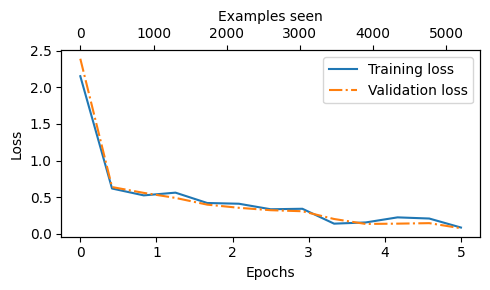

In [163]:
epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_losses))

plot_values(epochs_tensor, examples_seen_tensor, train_losses, val_losses)

4. 에포크 4와 5 이후에 비교ㅗ적 높은 훈련 정확도와 검증 정확도를 달성한다.
   - 에포크 전체에서 두 직선이 서로 가깝게 유지된다면 모델이 과적합되지 않았음을 나타낸다.

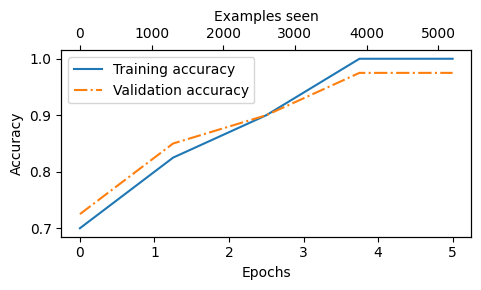

In [164]:
# linspace를 사용하여 정확도 플롯을 위한 x축 값 생성
#   - 에포크 수에 따라 x축 값을 생성합니다.
#   - len(train_accs)는 정확도가 기록된 횟수입니다.
epochs_tensor = torch.linspace(0, num_epochs, len(train_accs))
examples_seen_tensor = torch.linspace(0, examples_seen, len(train_accs))

plot_values(epochs_tensor, examples_seen_tensor, train_accs, val_accs, label="accuracy")

5. 전체 코드를 사용해 전체 데이터셋에서 훈련 세트, 검증 세트, 테스트 세트에 대한 성능을 계산한다.
   - 훈련 세트와 테스트 세트 정확도 사이에 약간의 차이는 훈련 데이터에 대한 과대적합이 미미하다고 볼 수 있다.

In [ ]:
train_accuracy = calc_accuracy_loader(train_loader, model, device)
val_accuracy = calc_accuracy_loader(val_loader, model, device)
test_accuracy = calc_accuracy_loader(test_loader, model, device)

print(f"최종 훈련 정확도: {train_accuracy*100:.2f}%")
print(f"최종 검증 정확도: {val_accuracy*100:.2f}%")
print(f"최종 테스트 정확도: {test_accuracy*100:.2f}%")

최종 훈련 정확도: 97.21%
최종 검증 정확도: 97.32%
최종 테스트 정확도: 95.67%


## Chapter 8 LLM을 스팸 분류기로 사용하기 <a class="anchor" id="chapter8"></a>


In [168]:
def classify_review(text, model, tokenizer, device, max_length=None, pad_token_id=50256):
    model.eval()

    # 모델에 대한 입력 준비
    input_ids = tokenizer.encode(text)
    supported_context_length = model.pos_emb.weight.shape[0]

    # 너무 긴 시퀀스 자르기
    input_ids = input_ids[:min(max_length, supported_context_length)]
    assert max_length is not None, (
        "max_length가 지정되지 않았습니다. 모델의 최대 문맥 길이를 사용하려면"
        "max_length=model.pos_emb.weight.shape[0]로 지정하세요."
    )
    assert max_length <= supported_context_length, (
        f"max_length({max_length})가 모델이 지원하는 문맥 길이({supported_context_length})를 초과했습니다."
    )
    # 또는 max_length=None인 경우를 안정적으로 처리하는 방법은 다음과 같습니다.
    # max_len = min(max_length, supported_context_length) if max_length else supported_context_length
    # input_ids = input_ids[:max_len]

    # 가장 긴 시퀀스로 패딩하기
    input_ids += [pad_token_id] * (max_length - len(input_ids))
    input_tensor = torch.tensor(input_ids, device=device).unsqueeze(0) # 배치 차원 추가

    # 모델 추론
    with torch.no_grad():
        logits = model(input_tensor)[:, -1, :]  # 마지막 출력 토큰의 로짓
    predicted_label = torch.argmax(logits, dim=-1).item()

    # 분류 결과 반환
    return "스팸" if predicted_label == 1 else "스팸아님"

In [169]:
text_1 = (
    "You are a winner you have been specially"
    " selected to receive $1000 cash or a $2000 award."
)

print(classify_review(text_1, model, tokenizer, device, max_length=train_dataset.max_length))

스팸


In [170]:
text_2 = (
    "Hey, just wanted to check if we're still on"
    " for dinner tonight? Let me know!"
)

print(classify_review(
    text_2, model, tokenizer, device, max_length=train_dataset.max_length
))

스팸아님


In [ ]:
# 나중에 다시 훈련하지 않고 모델을 재사용할 수 있도록 모델을 저장합니다.
torch.save(model.state_dict(), "review_classifier.pth")

In [ ]:
model_state_dict = torch.load("review_classifier.pth", map_location=device, weights_only=True)
model.load_state_dict(model_state_dict)